# ATDL Real Training Visualizations

This notebook visualizes preserved training, validation, KD, gradient, quantization, and compression artifacts. It does not train models and never accesses the official CIFAR-10 test set. All plots are generated from real project JSON histories, diagnostics, checkpoints, and report data.

In [1]:
from pathlib import Path
import json, math, os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if ROOT.name != 'ATDL-1': ROOT = Path('/home/vu-lab03-pc17/ATDL-1')
os.chdir(ROOT)
OUT = ROOT / 'plots' / 'training_visualizations'
OUT.mkdir(parents=True, exist_ok=True)
TEST_FORBIDDEN = ('test_batch', 'test_labels', 'official_test', 'cifar-10-batches-py/test')
def safe_json(path):
    if any(token in str(path).lower() for token in TEST_FORBIDDEN): raise RuntimeError(f'Test firewall blocked: {path}')
    return json.loads(Path(path).read_text())

STATE = safe_json(ROOT / 'research_state_checkpoint.json')
assert STATE['test_evaluation'] == 'LOCKED_NOT_RUN'
assert STATE['active_training'] is None
print('root:', ROOT)
print('output:', OUT)
print('official test:', STATE['test_evaluation'])

root: /home/vu-lab03-pc17/ATDL-1
output: /home/vu-lab03-pc17/ATDL-1/plots/training_visualizations
official test: LOCKED_NOT_RUN


## Experimental contract and architecture

```mermaid
flowchart LR
D[CIFAR-10 train 45k] --> T[FP32 ResNet-34 teacher]
D --> S[ResNet-18 student]
T --> K[Frozen teacher logits]
S --> Q[Per-channel symmetric TWN QAT + clipped STE]
Q --> KD[Temperature-scaled KD]
K --> KD
KD --> V[Validation-only selection]
```

The official test set is intentionally excluded. The student uses ternary Conv/FC deployed weights during forward passes, with latent FP32 training parameters.

In [2]:
def load_history(path):
    x = safe_json(ROOT / path)
    return x, x['history']

artifacts = {
    'Teacher FP32': 'training_history.json',
    'Task 3 ternary no-KD': 'experiments/histories/task3_b2_default/resnet18_ternary_seed44.json',
    'Task 4 vanilla KD': 'experiments/task4/histories/task4_b3_final_t2_lam09_rerun1/seed42.json',
    'DKD': 'experiments/task4/histories/task5_dkd_final_t2_lam09_a1_b8_r1/seed42.json',
    'DIST': 'experiments/task4/histories/task6_dist_screen_t2_lam09_i1_a1_r1/seed42.json',
}
loaded = {name: load_history(path) for name, path in artifacts.items()}
for name, (meta, hist) in loaded.items(): print(name, len(hist.get('val_acc', [])), 'epochs', list(hist))

Teacher FP32 200 epochs ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'lr', 'gap']
Task 3 ternary no-KD 200 epochs ['gap', 'lr', 'train_acc', 'train_loss', 'val_acc', 'val_loss']
Task 4 vanilla KD 200 epochs ['ce_grad_norm', 'ce_loss', 'gap', 'grad_cosine', 'kd_grad_norm', 'kd_loss', 'lr', 'total_loss', 'train_acc', 'val_acc', 'val_loss', 'weighted_ce', 'weighted_kd']
DKD 200 epochs ['ce_grad_norm', 'ce_loss', 'gap', 'grad_cosine', 'kd_grad_norm', 'kd_loss', 'lr', 'total_loss', 'train_acc', 'val_acc', 'val_loss', 'weighted_ce', 'weighted_kd']
DIST 50 epochs ['ce_grad_norm', 'ce_loss', 'gap', 'grad_cosine', 'kd_grad_norm', 'kd_loss', 'lr', 'total_loss', 'train_acc', 'val_acc', 'val_loss', 'weighted_ce', 'weighted_kd']


## Teacher pre-training to post-training behavior

This uses the actual 200-epoch teacher history. The first point is the early-training state and the final/best points show post-training behavior; no synthetic baseline is added.

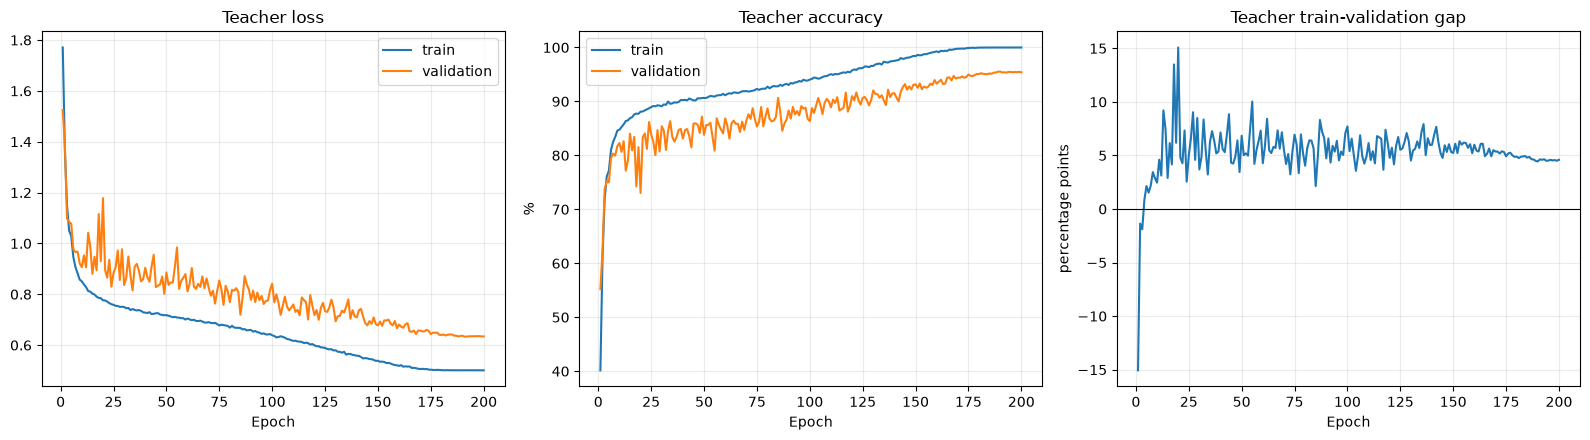

In [3]:
teacher = loaded['Teacher FP32'][1]
epochs = np.arange(1, len(teacher['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(epochs, teacher['train_loss'], label='train'); axes[0].plot(epochs, teacher['val_loss'], label='validation'); axes[0].set_title('Teacher loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=.25)
axes[1].plot(epochs, np.array(teacher['train_acc'])*100, label='train'); axes[1].plot(epochs, np.array(teacher['val_acc'])*100, label='validation'); axes[1].set_title('Teacher accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('%'); axes[1].legend(); axes[1].grid(alpha=.25)
axes[2].plot(epochs, np.array(teacher['gap'])*100); axes[2].axhline(0,color='black',lw=.8); axes[2].set_title('Teacher train-validation gap'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('percentage points'); axes[2].grid(alpha=.25)
fig.tight_layout(); fig.savefig(OUT/'teacher_pre_post_training.png', dpi=180); plt.show()

## Student QAT and KD training curves

These curves compare actual preserved histories. A curve is omitted only when the artifact did not log that metric.

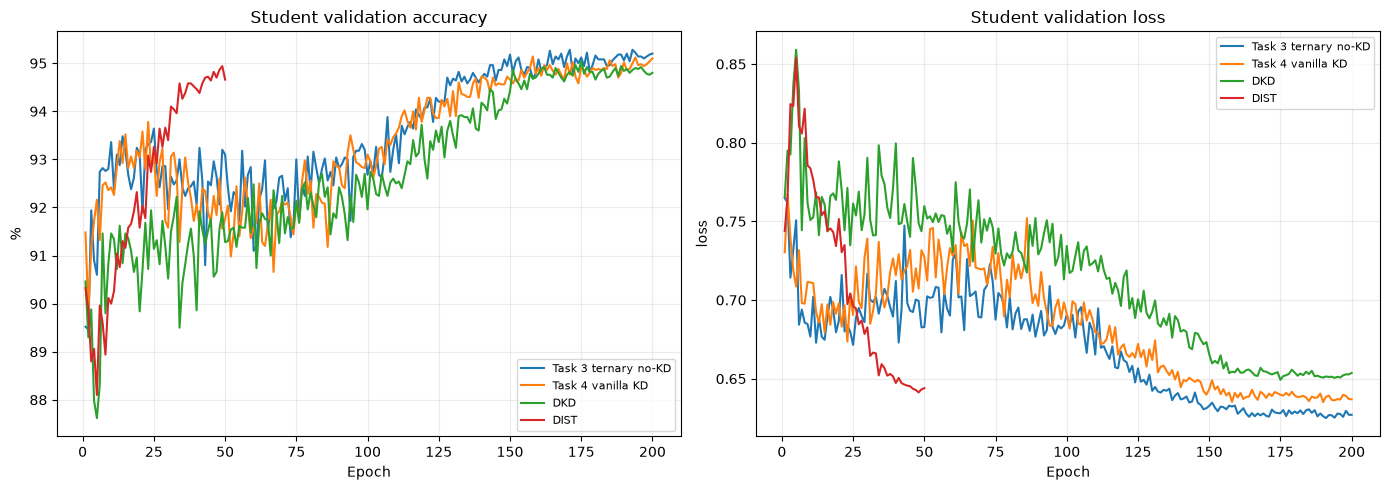

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in ('Task 3 ternary no-KD', 'Task 4 vanilla KD', 'DKD', 'DIST'):
    hist = loaded[name][1]; val = hist.get('val_acc', [])
    if val: axes[0].plot(np.arange(1,len(val)+1), np.array(val)*100, label=name)
    loss = hist.get('val_loss', [])
    if loss: axes[1].plot(np.arange(1,len(loss)+1), loss, label=name)
axes[0].set_title('Student validation accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('%')
axes[1].set_title('Student validation loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('loss')
for ax in axes: ax.grid(alpha=.25); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUT/'student_training_comparison.png', dpi=180); plt.show()

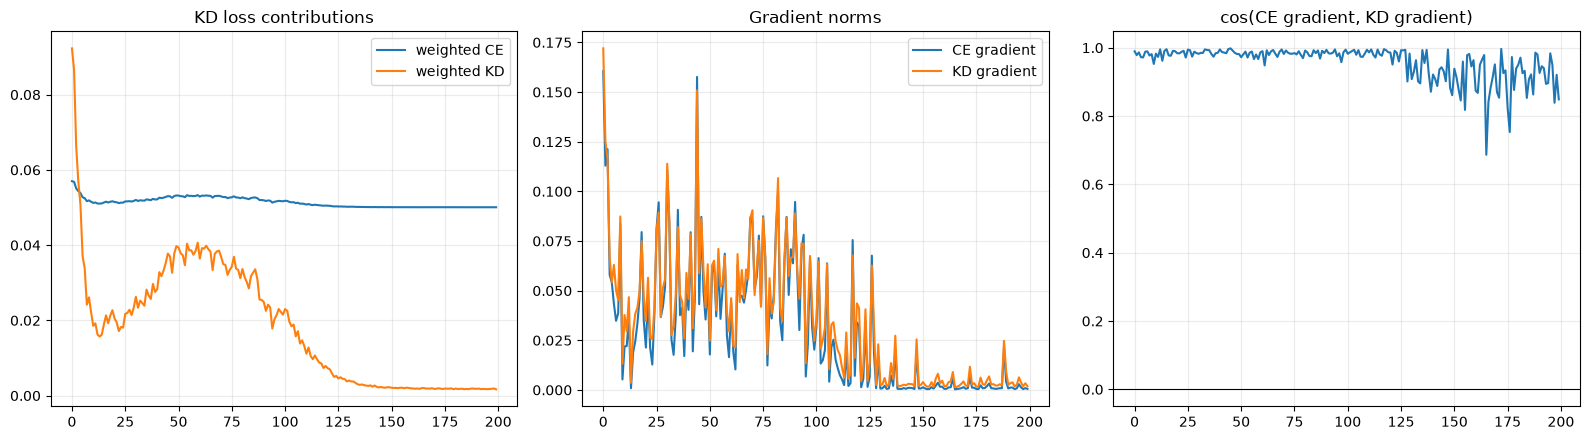

In [5]:
hist = loaded['Task 4 vanilla KD'][1]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(hist['weighted_ce'], label='weighted CE'); axes[0].plot(hist['weighted_kd'], label='weighted KD'); axes[0].set_title('KD loss contributions'); axes[0].legend(); axes[0].grid(alpha=.25)
axes[1].plot(hist['ce_grad_norm'], label='CE gradient'); axes[1].plot(hist['kd_grad_norm'], label='KD gradient'); axes[1].set_title('Gradient norms'); axes[1].legend(); axes[1].grid(alpha=.25)
axes[2].plot(hist['grad_cosine']); axes[2].axhline(0,color='black',lw=.8); axes[2].set_title('cos(CE gradient, KD gradient)'); axes[2].grid(alpha=.25)
fig.tight_layout(); fig.savefig(OUT/'kd_loss_and_gradient_diagnostics.png', dpi=180); plt.show()

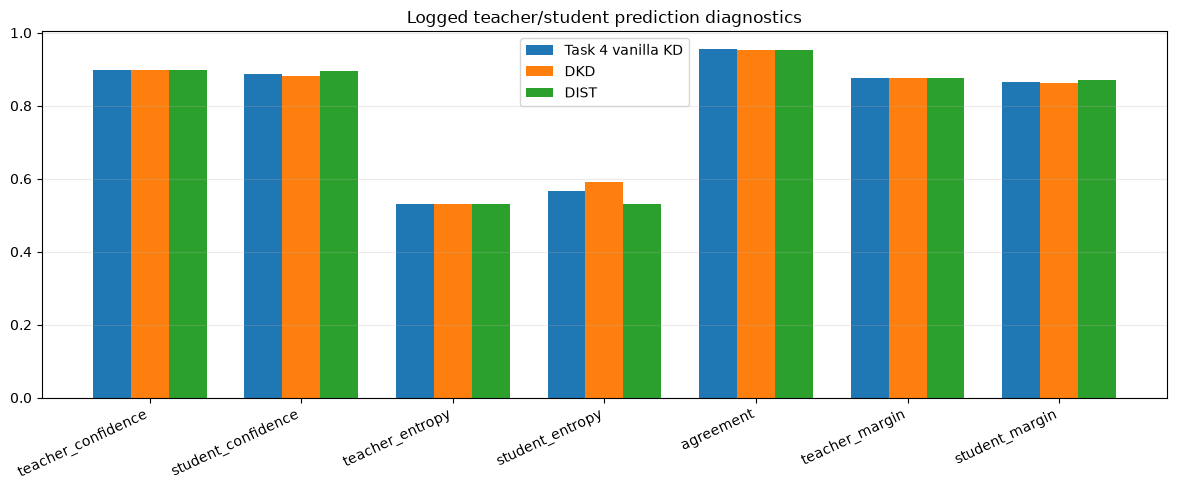

Unavailable diagnostics: representation similarity/CKA was not logged in preserved runs.


In [6]:
diagnostic_paths = {
    'Task 4 vanilla KD': 'experiments/task4/diagnostics/task4_b3_final_t2_lam09_rerun1/seed42.json',
    'DKD': 'experiments/task4/diagnostics/task5_dkd_final_t2_lam09_a1_b8_r1/seed42.json',
    'DIST': 'experiments/task4/diagnostics/task6_dist_screen_t2_lam09_i1_a1_r1/seed42.json',
}
rows = {}
for name, path in diagnostic_paths.items():
    x = safe_json(ROOT/path); rows[name] = x.get('validation_kd', x.get('validation_kd_diagnostics', {}))
metrics = ['teacher_confidence','student_confidence','teacher_entropy','student_entropy','agreement','teacher_margin','student_margin']
fig, ax = plt.subplots(figsize=(12,5)); x=np.arange(len(metrics)); width=.25
for i,(name,row) in enumerate(rows.items()): ax.bar(x+i*width,[row.get(m,np.nan) for m in metrics],width,label=name)
ax.set_xticks(x+width); ax.set_xticklabels(metrics,rotation=25,ha='right'); ax.set_title('Logged teacher/student prediction diagnostics'); ax.legend(); ax.grid(axis='y',alpha=.25)
fig.tight_layout(); fig.savefig(OUT/'prediction_diagnostics.png', dpi=180); plt.show()
print('Unavailable diagnostics: representation similarity/CKA was not logged in preserved runs.')

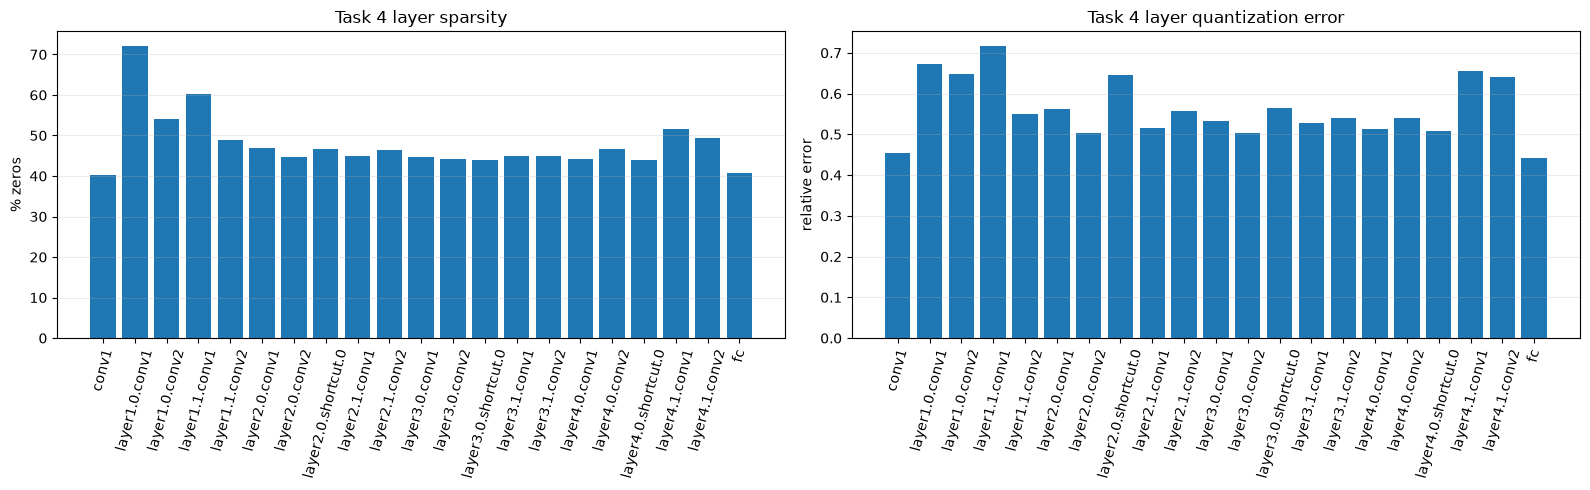

Task 3 and Task 4 diagnostics loaded from: experiments/histories/task3_b2_default/resnet18_ternary_seed44.json experiments/task4/histories/task4_b3_final_t2_lam09_remaining_rerun1/seed44.json


In [7]:
quant_paths = {
    "Task 3": "experiments/histories/task3_b2_default/resnet18_ternary_seed44.json",
    "Task 4": "experiments/task4/histories/task4_b3_final_t2_lam09_remaining_rerun1/seed44.json",
    "DKD": "experiments/task4/histories/task5_dkd_final_t2_lam09_a1_b8_r1/seed42.json",
    "DIST": "experiments/task4/histories/task6_dist_screen_t2_lam09_i1_a1_r1/seed42.json",
}
quant_records = {}
for name, path in quant_paths.items():
    source = safe_json(ROOT / path)
    quant_records[name] = source.get("quant_diagnostics", source.get("ternary", {}))

quant = quant_records["Task 4"]
layers = quant.get("layers", [])
if layers:
    names = [record["layer"] for record in layers]
    zero = [100 * record["zero_frac"] for record in layers]
    error = [record["quant_error"] for record in layers]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].bar(names, zero)
    axes[0].set_title("Task 4 layer sparsity")
    axes[0].set_ylabel("% zeros")
    axes[1].bar(names, error)
    axes[1].set_title("Task 4 layer quantization error")
    axes[1].set_ylabel("relative error")
    for axis in axes:
        axis.tick_params(axis="x", rotation=75)
        axis.grid(axis="y", alpha=.25)
    fig.tight_layout()
    fig.savefig(OUT / "layerwise_quantization.png", dpi=180)
    plt.show()
    print("Task 3 and Task 4 diagnostics loaded from:", quant_paths["Task 3"], quant_paths["Task 4"])
else:
    print("Layer-wise quantization diagnostics unavailable in this artifact.")

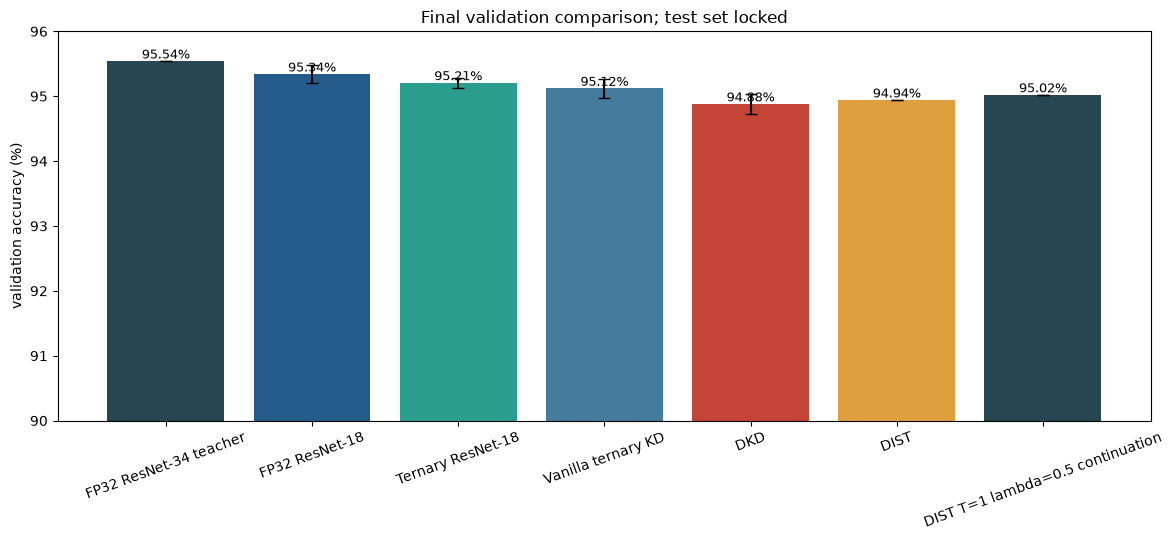

In [8]:
comparison = safe_json(ROOT/'report/final/final_comparison.json')['rows']
fig, ax = plt.subplots(figsize=(12,5.5))
labels=[r['model'] for r in comparison]; means=[100*r['validation_mean'] for r in comparison]; errs=[100*(r.get('validation_std') or 0) for r in comparison]
bars=ax.bar(labels,means,yerr=errs,capsize=4,color=['#264653','#245b8a','#2a9d8f','#457b9d','#c44536','#e09f3e']); ax.set_ylim(90,96); ax.set_ylabel('validation accuracy (%)'); ax.set_title('Final validation comparison; test set locked'); ax.tick_params(axis='x',rotation=20)
for bar,value in zip(bars,means): ax.text(bar.get_x()+bar.get_width()/2,value+.04,f'{value:.2f}%',ha='center',fontsize=9)
fig.tight_layout(); fig.savefig(OUT/'final_validation_comparison.png', dpi=180); plt.show()

In [9]:
compression = safe_json(ROOT/'report/final/compression_analysis.json')
display(Markdown('### Compression accounting'))
display(compression)
print('This is theoretical storage compression only; no runtime speedup is claimed.')
print('Generated plot files:')
for p in sorted(OUT.glob('*.png')): print(p.relative_to(ROOT))

### Compression accounting

{'parameter_count': 11173962,
 'fp32_bits': 357566784,
 'ideal_ternary_bits_plus_64_scales': 17712358.75448317,
 'theoretical_ratio': 20.187417664487874,
 'sparsity_reference': 0.4714,
 'caveat': 'The ratio excludes packing/runtime overhead and does not imply hardware speedup.'}

This is theoretical storage compression only; no runtime speedup is claimed.
Generated plot files:
plots/training_visualizations/final_validation_comparison.png
plots/training_visualizations/kd_loss_and_gradient_diagnostics.png
plots/training_visualizations/layerwise_quantization.png
plots/training_visualizations/prediction_diagnostics.png
plots/training_visualizations/student_training_comparison.png
plots/training_visualizations/teacher_pre_post_training.png


## Resumable continuation training

Task 4, DKD, and the original DIST screen are complete and are loaded from preserved artifacts. The only implemented remaining branch is a bounded one-seed DIST continuation. QTRD, attention transfer, and RKD are not implemented in the production trainer and are recorded as deferred rather than fabricated.

In [10]:
import subprocess

CONTINUATION = {
    "run_name": "task7_dist_t1_lam05_r1",
    "config": ROOT / "configs/kd/resnet18_ternary_dist_t1_lam05_continuation.yaml",
    "summary": ROOT / "results/task4/task7_dist_t1_lam05_r1_summary.json",
}
assert CONTINUATION["config"].exists()
assert STATE["test_evaluation"] == "LOCKED_NOT_RUN"
assert STATE["active_training"] is None
if CONTINUATION["summary"].exists():
    continuation_status = "already-complete; preserved artifact loaded"
else:
    command = [
        str(ROOT / ".venv/bin/python"), str(ROOT / "scripts/train_student_vanilla_kd.py"),
        "--kd-mode", "dist", "--config", str(CONTINUATION["config"]),
    ]
    print("Launching one-seed continuation:", " ".join(command))
    completed = subprocess.run(command, cwd=ROOT, check=True)
    continuation_status = f"trained; returncode={completed.returncode}"
print({"run_name": CONTINUATION["run_name"], "status": continuation_status, "test": "LOCKED_NOT_RUN"})

{'run_name': 'task7_dist_t1_lam05_r1', 'status': 'already-complete; preserved artifact loaded', 'test': 'LOCKED_NOT_RUN'}
